<a href="https://colab.research.google.com/github/kumarmohit0911/robust-gas-classification-mq-sensors/blob/main/gas_sensor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/Gas_Sensors_Measurements (2).csv")

In [ ]:
df

,Serial Number,MQ2,MQ3,MQ5,MQ6,MQ7,MQ8,MQ135,Gas,Corresponding Image Name
0,0,555,515,377,338,666,451,416,NoGas,0_NoGas
1,1,555,516,377,339,666,451,416,NoGas,1_NoGas
2,2,556,517,376,337,666,451,416,NoGas,2_NoGas
3,3,556,516,376,336,665,451,416,NoGas,3_NoGas
4,4,556,516,376,337,665,451,416,NoGas,4_NoGas
...,...,...,...,...,...,...,...,...,...,...
6395,1595,658,445,455,414,491,321,436,Mixture,1595_Mixture
6396,1596,650,444,451,411,486,317,431,Mixture,1596_Mixture
6397,1597,630,443,446,407,474,312,429,Mixture,1597_Mixture
6398,1598,632,443,444,405,471,309,430,Mixture,1598_Mixture


In [ ]:
df.shape

(6400, 10)

# ***Making a rough wrokflow and diagram of the neural network in my rough notebook.***

lets make a neural network with 10 input layer and first hidden layer with 10 neurons which will take 10 input and 6 outputr and then 2nd hidden layer with 3 neurons which will be taking 6 input and 1 output and then finally 1 output layer with one single neuron. the first hidden layer will have relu as its actibation fuction and so do the second and third but the output layer will have sigmoid as its output layer function.

**The Work flow**

Loading the gass sensor data set and then doing a bit of data analysis and then building a simple neural network using pytorch. And after that we will be evaluating the model and will be checking the accuracies and after that we will be doinh Hyperparameter tuning and changing the activation functions and doing other things to increase the acuuracy.

***Lets Begin***

In [5]:
# calling all the dependencies
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset,DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [6]:
#for reproducibility
torch.manual_seed(42)

In [7]:
# loading the data set
df = pd.read_csv("/content/Gas_Sensors_Measurements (2).csv")

In [8]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [9]:
df

,Serial Number,MQ2,MQ3,MQ5,MQ6,MQ7,MQ8,MQ135,Gas,Corresponding Image Name
0,0,555,515,377,338,666,451,416,NoGas,0_NoGas
1,1,555,516,377,339,666,451,416,NoGas,1_NoGas
2,2,556,517,376,337,666,451,416,NoGas,2_NoGas
3,3,556,516,376,336,665,451,416,NoGas,3_NoGas
4,4,556,516,376,337,665,451,416,NoGas,4_NoGas
...,...,...,...,...,...,...,...,...,...,...
6395,1595,658,445,455,414,491,321,436,Mixture,1595_Mixture
6396,1596,650,444,451,411,486,317,431,Mixture,1596_Mixture
6397,1597,630,443,446,407,474,312,429,Mixture,1597_Mixture
6398,1598,632,443,444,405,471,309,430,Mixture,1598_Mixture


In [10]:
df = df.drop(["Serial Number","Corresponding Image Name"],axis = 1)


In [11]:
df

,MQ2,MQ3,MQ5,MQ6,MQ7,MQ8,MQ135,Gas
0,555,515,377,338,666,451,416,NoGas
1,555,516,377,339,666,451,416,NoGas
2,556,517,376,337,666,451,416,NoGas
3,556,516,376,336,665,451,416,NoGas
4,556,516,376,337,665,451,416,NoGas
...,...,...,...,...,...,...,...,...
6395,658,445,455,414,491,321,436,Mixture
6396,650,444,451,411,486,317,431,Mixture
6397,630,443,446,407,474,312,429,Mixture
6398,632,443,444,405,471,309,430,Mixture


In [12]:
df['Gas'].head(3000)

,Gas
0,NoGas
1,NoGas
2,NoGas
3,NoGas
4,NoGas
...,...
2995,Perfume
2996,Perfume
2997,Perfume
2998,Perfume


I guess this not binary problem ... after looking over the dataset i got to know that it is rather a multiclass classification problem than a binary problem. so instead of using sigmoid we gonna be using softmax.

now we also need to do encoding here.

 **Change in the architechture of the neural network**

 now we will have 32 layers in 1st hidden layer and at the end we gonna have 4 layers each representing each label of multiclass classification.

**we gonna encode the four features in 1,2,3,4**

1--> no gas

2--> perfume

3--> smoke

4--> mixture

In [13]:
for i in df['Gas']:
  if i == 'NoGas':
    df['Gas'] = df['Gas'].replace(i,0)
  if i == 'Perfume':
    df['Gas'] = df['Gas'].replace(i,1)
  if i == 'Smoke':
    df['Gas'] = df['Gas'].replace(i,2)
  if i == 'Mixture':
    df['Gas'] = df['Gas'].replace(i,3)

/tmp/ipython-input-512672298.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gas'] = df['Gas'].replace(i,3)


In [14]:
df['Gas'].head(3000)

,Gas
0,0
1,0
2,0
3,0
4,0
...,...
2995,1
2996,1
2997,1
2998,1


In [15]:
# NOW CHECKING THE DATASET
df

,MQ2,MQ3,MQ5,MQ6,MQ7,MQ8,MQ135,Gas
0,555,515,377,338,666,451,416,0
1,555,516,377,339,666,451,416,0
2,556,517,376,337,666,451,416,0
3,556,516,376,336,665,451,416,0
4,556,516,376,337,665,451,416,0
...,...,...,...,...,...,...,...,...
6395,658,445,455,414,491,321,436,3
6396,650,444,451,411,486,317,431,3
6397,630,443,446,407,474,312,429,3
6398,632,443,444,405,471,309,430,3


In [16]:
X = df[['MQ2','MQ3','MQ5', 'MQ6',	'MQ7',	'MQ8',	'MQ135']]
y = df['Gas']

In [17]:
X

,MQ2,MQ3,MQ5,MQ6,MQ7,MQ8,MQ135
0,555,515,377,338,666,451,416
1,555,516,377,339,666,451,416
2,556,517,376,337,666,451,416
3,556,516,376,336,665,451,416
4,556,516,376,337,665,451,416
...,...,...,...,...,...,...,...
6395,658,445,455,414,491,321,436
6396,650,444,451,411,486,317,431
6397,630,443,446,407,474,312,429
6398,632,443,444,405,471,309,430


In [18]:
y

,Gas
0,0
1,0
2,0
3,0
4,0
...,...
6395,3
6396,3
6397,3
6398,3


In [19]:
# scaling the features

sc = StandardScaler()
X = sc.fit_transform(X)

In [20]:
X

array([[-1.31953286,  0.75379067, -0.49542129, ...,  1.20355277,
        -0.60575265, -0.00948193],
       [-1.31953286,  0.76801976, -0.49542129, ...,  1.20355277,
        -0.60575265, -0.00948193],
       [-1.30876937,  0.78224886, -0.51338497, ...,  1.20355277,
        -0.60575265, -0.00948193],
       ...,
       [-0.51227134, -0.27070406,  0.74407222, ..., -1.10616061,
        -1.52623114,  0.16006393],
       [-0.49074437, -0.27070406,  0.70814487, ..., -1.14224988,
        -1.54609758,  0.17310592],
       [-0.47998088, -0.28493315,  0.67221753, ..., -1.17833915,
        -1.56596402,  0.22527388]])

In [21]:
# Train test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state=42)

In [22]:
X_train

array([[ 0.73629314,  0.8960816 ,  1.10334571, ...,  1.39602888,
         1.31467008,  1.07300323],
       [-1.50251213, -1.6793843 , -0.72894905, ...,  0.0727556 ,
         0.20877147, -1.53539475],
       [-0.60914272, -0.35607862,  0.65425385, ..., -0.98586303,
        -1.1024137 ,  0.17310592],
       ...,
       [-0.51227134, -0.66911867,  0.07941628, ..., -1.17833915,
        -1.66529623, -0.24423775],
       [-1.50251213, -0.69757686, -0.19003883, ..., -1.32269623,
        -1.44676537,  0.00356006],
       [ 0.95156288,  0.98145616,  0.29498037, ...,  0.18102341,
         0.65907749,  0.77303746]])

In [23]:
X_train.shape[1]

7

In [24]:
y_test.head(391)

,Gas
1992,1
2775,1
4162,2
5502,3
132,0
...,...
2770,1
926,0
3412,2
1600,1


In [25]:
# creating custom dataset

class CustomDataset(Dataset):
  def __init__(self,features, labels):
    self.features = torch.tensor(features, dtype = torch.float32)
    self.labels = torch.tensor(labels, dtype = torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,index):
    return self.features[index],self.labels[index]


In [26]:
train_dataset = CustomDataset(X_train,y_train.values)
test_dataset = CustomDataset(X_test,y_test.values)

In [27]:
y_train.shape

(5120,)

In [28]:
len(train_dataset)

5120

In [60]:
# Creating train and test dataloader
train_loader = DataLoader(train_dataset,batch_size =  32, shuffle =True)
test_loader = DataLoader(test_dataset,batch_size = 32,shuffle = True)

**Neural Network using PYTORCH**

In [30]:
class MyNN(nn.Module):

  def __init__(self, num_features):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features,64),
        nn.ReLU(),
        nn.Linear(64,32),
        nn.ReLU(),
        nn.Linear(32,16),
        nn.ReLU(),
        nn.Linear(16,4),
        #nn.Softmax(dim = 1)
    )

  def forward(self,x):

    return self.model(x)


In [103]:
#setting learning rate and epochs
epochs = 200
learning_rate = 0.1

In [104]:
#instantiate the model
model = MyNN(X_train.shape[1])
model = model.to(device)

In [105]:
#loss function
criterion = nn.CrossEntropyLoss()

In [106]:
optimizer = optim.SGD(model.parameters(),lr = learning_rate)

***TRAINING LOOP***

In [107]:
for epoch in range(epochs):
  total_epoch_loss = 0
  for batch_features,batch_labels in train_loader:

    #modifying training loop data to gpu
    batch_features,batch_labels = batch_features.to(device), batch_labels.to(device)


    #forward pass
    outputs = model(batch_features)

    #calculate loss
    loss = criterion(outputs,batch_labels)

    #backward pass
    optimizer.zero_grad()
    loss.backward()

    #update weights
    optimizer.step()

    total_epoch_loss += loss.item()

  print(f"Epoch {epoch+1}/{epochs}, Loss: {total_epoch_loss/len(train_loader)}")


Epoch 1/200, Loss: 0.6582542545162141
Epoch 2/200, Loss: 0.30155083341524
Epoch 3/200, Loss: 0.22061543059535324
Epoch 4/200, Loss: 0.19513010785449297
Epoch 5/200, Loss: 0.1765155374072492
Epoch 6/200, Loss: 0.16082860373426228
Epoch 7/200, Loss: 0.15911515987245367
Epoch 8/200, Loss: 0.1480547913699411
Epoch 9/200, Loss: 0.14592736228369177
Epoch 10/200, Loss: 0.13902219132287427
Epoch 11/200, Loss: 0.13744376343674958
Epoch 12/200, Loss: 0.13814306626445613
Epoch 13/200, Loss: 0.13409463355201295
Epoch 14/200, Loss: 0.13030301386024803
Epoch 15/200, Loss: 0.12901181624038144
Epoch 16/200, Loss: 0.127164782572072
Epoch 17/200, Loss: 0.13090481719118544
Epoch 18/200, Loss: 0.12291388020967134
Epoch 19/200, Loss: 0.12696840625139885
Epoch 20/200, Loss: 0.12266267163213343
Epoch 21/200, Loss: 0.11744098234339617
Epoch 22/200, Loss: 0.11964099496835842
Epoch 23/200, Loss: 0.11958559688646346
Epoch 24/200, Loss: 0.1199873587815091
Epoch 25/200, Loss: 0.11573023661621847
Epoch 26/200, Loss

Resuming......


In [108]:
# model is trained so now we will start testing or evaluating the model.
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=4, bias=True)
  )
)

In [109]:
#Test Code
total = 0
correct = 0
with torch.no_grad():
  for batch_features,batch_labels in test_loader:
    batch_features,batch_labels = batch_features.to(device),batch_labels.to(device)
    outputs = model(batch_features)
    _,predicted = torch.max(outputs.data,1)
    total += batch_labels.shape[0]
    correct += (predicted == batch_labels).sum().item()

accuracy = correct/total
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 97.19%


In [110]:
# so we got the accuracy as 97 percent without any further tuning , that is impressive.

In [111]:
class_map = {
    0: 'NoGas',
    1: 'Perfume',
    2: 'Smoke',
    3: 'Mixture'
}


In [113]:
new_sample = [566,	364,	314,	355,	576,	557,	286]
new_sample_scaled = sc.transform([new_sample])




model.eval()
with torch.no_grad():
    sample_tensor = torch.tensor(new_sample_scaled, dtype=torch.float32).to(device)

    output = model(sample_tensor)          # shape: [1, num_classes]
    predicted = torch.argmax(output, dim=1)  # class index

print("Predicted Gas:", class_map[predicted.item()])


Predicted Gas: Smoke


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


**Thank You !!**

In [67]:
import torch
import numpy as np
y_true = []
y_pred = []
model.eval()
with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features,batch_labels = batch_features.to(device),batch_labels.to(device)

        outputs = model(batch_features)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(batch_labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())


In [68]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
print(cm)


[[310  37   0   0]
 [  9 311   0   0]
 [  0   0 309   0]
 [  0   0   0 304]]


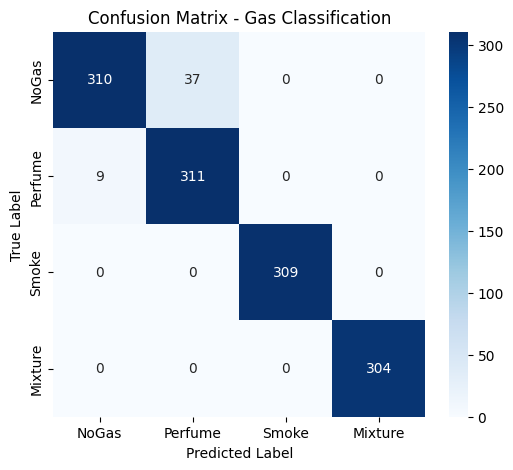

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = ['NoGas', 'Perfume', 'Smoke', 'Mixture']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Gas Classification")
plt.show()


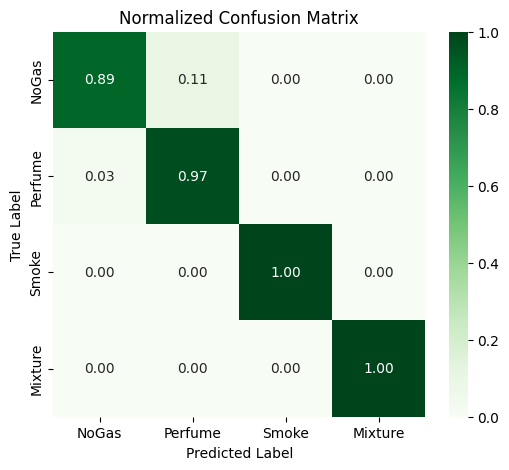

In [70]:
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.show()


In [71]:
import torch
import numpy as np

y_true = []
y_pred = []
y_prob = []

model.eval()
with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features,batch_labels = batch_features.to(device),batch_labels.to(device)

        outputs = model(batch_features)
        probs = torch.softmax(outputs, dim=1)

        y_true.extend(batch_labels.cpu().numpy())
        y_pred.extend(torch.argmax(probs, dim=1).cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)


In [72]:
from sklearn.metrics import f1_score

f1_macro = f1_score(y_true, y_pred, average='macro')
f1_micro = f1_score(y_true, y_pred, average='micro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print(f"F1 Score (Macro):    {f1_macro:.4f}")
print(f"F1 Score (Micro):    {f1_micro:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")


F1 Score (Macro):    0.9655
F1 Score (Micro):    0.9641
F1 Score (Weighted): 0.9641


In [73]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=list(class_map.values())
))


              precision    recall  f1-score   support

       NoGas       0.97      0.89      0.93       347
     Perfume       0.89      0.97      0.93       320
       Smoke       1.00      1.00      1.00       309
     Mixture       1.00      1.00      1.00       304

    accuracy                           0.96      1280
   macro avg       0.97      0.97      0.97      1280
weighted avg       0.97      0.96      0.96      1280



In [74]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

num_classes = len(class_map)

# One-hot encode true labels
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))

roc_auc_macro = roc_auc_score(
    y_true_bin,
    y_prob,
    average="macro",
    multi_class="ovr"
)

roc_auc_weighted = roc_auc_score(
    y_true_bin,
    y_prob,
    average="weighted",
    multi_class="ovr"
)

print(f"ROC-AUC (Macro):    {roc_auc_macro:.4f}")
print(f"ROC-AUC (Weighted): {roc_auc_weighted:.4f}")


ROC-AUC (Macro):    0.9974
ROC-AUC (Weighted): 0.9973


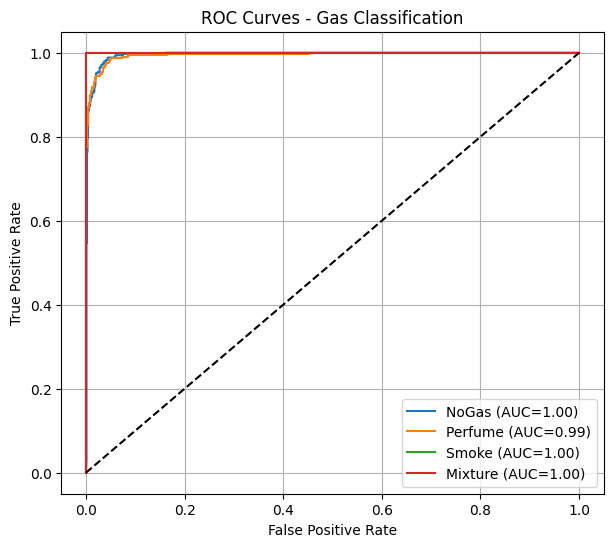

In [75]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7,6))

for i, label in class_map.items():
    fpr, tpr, _ = roc_curve(y_true_bin[:, i-1], y_prob[:, i-1])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Gas Classification")
plt.legend()
plt.grid()
plt.show()


In [76]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
import numpy as np
import torch

model.eval()

for noise in [0.0, 0.05, 0.10, 0.20]:
    y_true_noise = []
    y_prob_noise = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch,y_batch = batch_features.to(device),batch_labels.to(device)

            X_noisy = X_batch + noise * torch.randn_like(X_batch)
            outputs = model(X_noisy)
            probs = torch.softmax(outputs, dim=1)

            y_true_noise.extend(y_batch.cpu().numpy())
            y_prob_noise.extend(probs.cpu().numpy())

    y_true_noise = np.array(y_true_noise)
    y_prob_noise = np.array(y_prob_noise)

    num_classes = y_prob_noise.shape[1]

    y_true_bin = label_binarize(
        y_true_noise,
        classes=list(range(num_classes))
    )

    auc_macro = roc_auc_score(
        y_true_bin,
        y_prob_noise,
        average="macro",
        multi_class="ovr"
    )

    print(f"Noise {noise:.2f} → Macro ROC-AUC: {auc_macro:.4f}")


Noise 0.00 → Macro ROC-AUC: 1.0000
Noise 0.05 → Macro ROC-AUC: 0.9974
Noise 0.10 → Macro ROC-AUC: 0.9851
Noise 0.20 → Macro ROC-AUC: 0.9626


In [ ]:
print(len(train_dataset), len(test_dataset))


5120 1280


In [ ]:
print(np.unique(y_true, return_counts=True))


(array([0, 1, 2, 3]), array([347, 320, 309, 304]))


<Axes: >

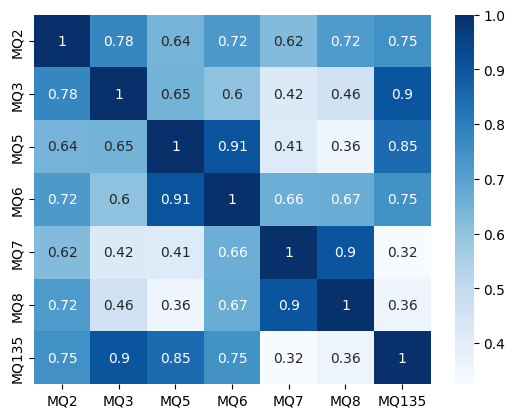

In [ ]:
sns.heatmap(df.drop('Gas',axis=1).corr(), annot=True, cmap='Blues')


The sensors react in very similar ways and each gas produces a clearly different response pattern, so the model doesn’t have to work hard
the data already separates the classes.